# Customer Term Deposit Prediction


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                              RocCurveDisplay, classification_report)

RANDOM_STATE = 42
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
pd.set_option('display.max_columns', None)


In [3]:
df = pd.read_csv('bank-full.csv', sep=';')

In [4]:
df.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [5]:
df.shape



(45211, 17)

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [7]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(numeric_cols)


['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


In [8]:
categorical_cols = [c for c in df.columns if c not in numeric_cols]
print(categorical_cols)

['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']


In [9]:
print(df.isnull().sum()[df.isnull().sum() > 0])

for c in categorical_cols:
    n = (df[c] == 'unknown').sum()
    if n > 0:
        print(f"  {c}: {n} ({n/len(df)*100:.1f}%)")

print(df.duplicated().sum())


Series([], dtype: int64)
  job: 288 (0.6%)
  education: 1857 (4.1%)
  contact: 13020 (28.8%)
  poutcome: 36959 (81.7%)
0


y
no     39922
yes     5289
Name: count, dtype: int64
y
no     88.3
yes    11.7
Name: proportion, dtype: float64


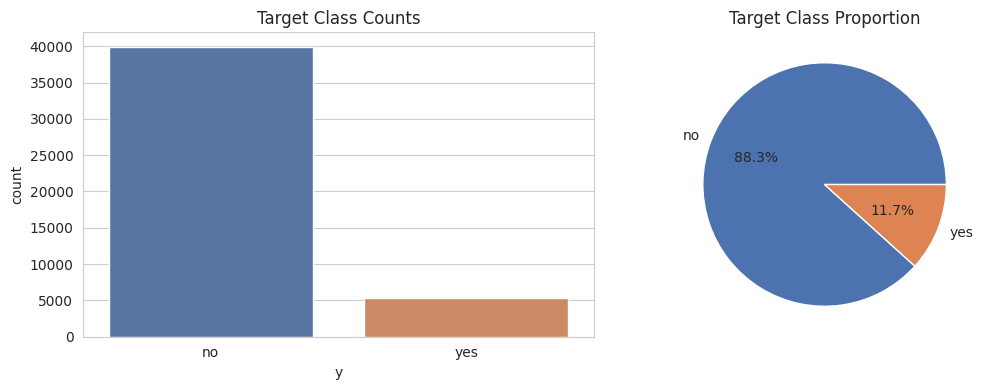

In [11]:
target_counts = df['y'].value_counts()
target_pct = df['y'].value_counts(normalize=True) * 100
print(target_counts)
print(target_pct.round(2))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x='y', data=df, ax=ax[0], palette=['#4C72B0', '#DD8452'])
ax[0].set_title('Target Class Counts')
ax[1].pie(target_counts, labels=target_counts.index, autopct='%1.1f%%',
          colors=['#4C72B0', '#DD8452'])
ax[1].set_title('Target Class Proportion')
plt.tight_layout()
plt.savefig('01_target_distribution.png', dpi=110)
plt.show()


In [12]:
df[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


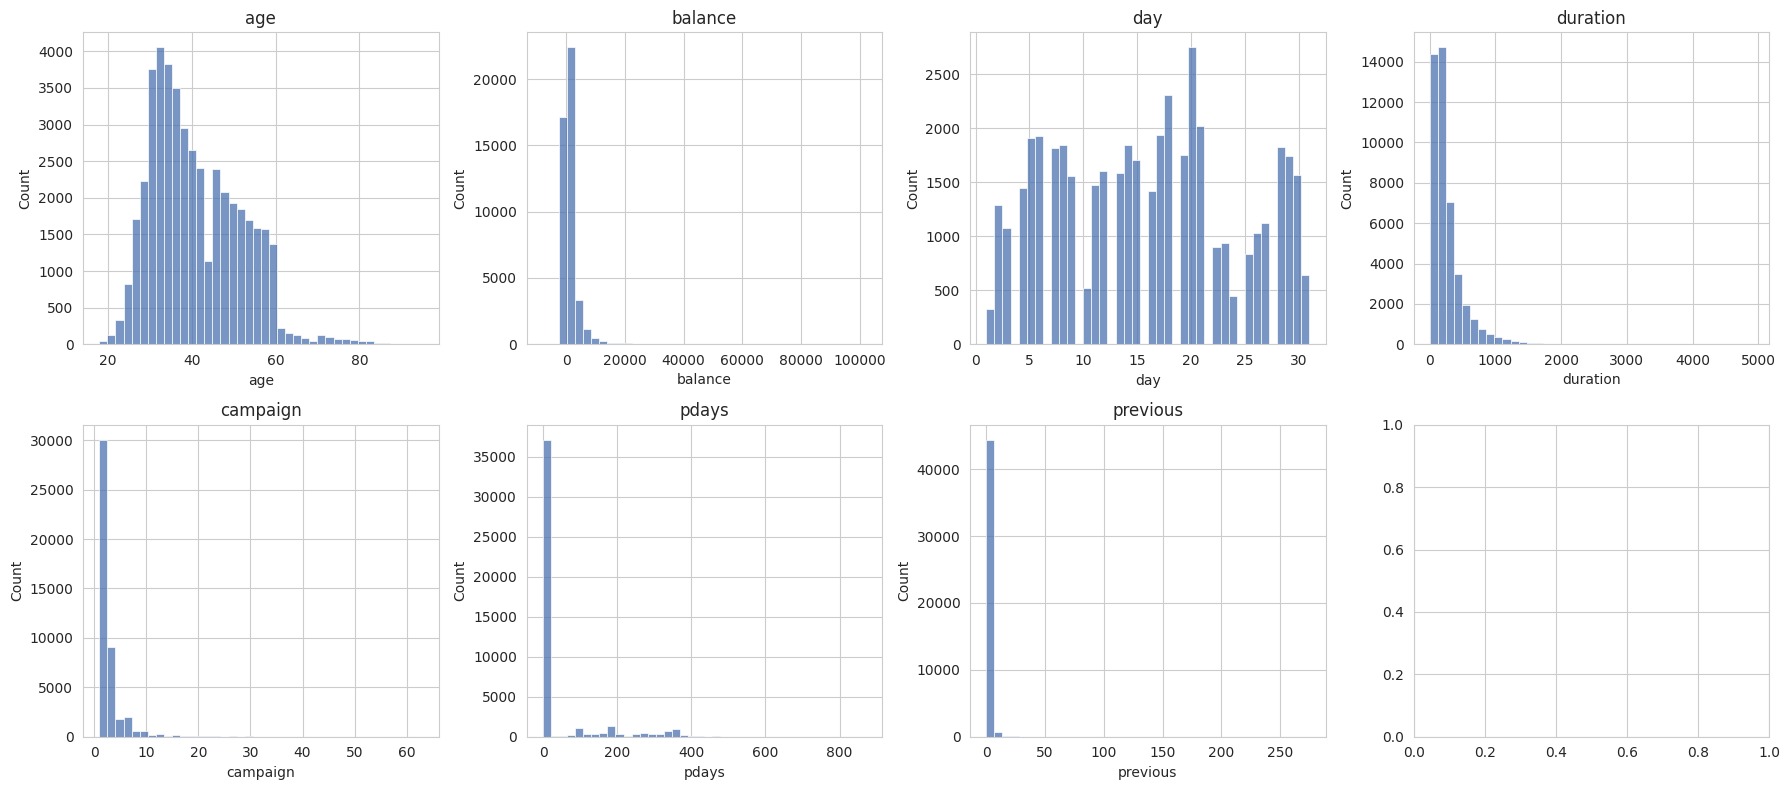

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(df[col], bins=40, ax=ax, color='#4C72B0')
    ax.set_title(col)
plt.tight_layout()
plt.savefig('02_numeric_distributions.png', dpi=110)
plt.show()


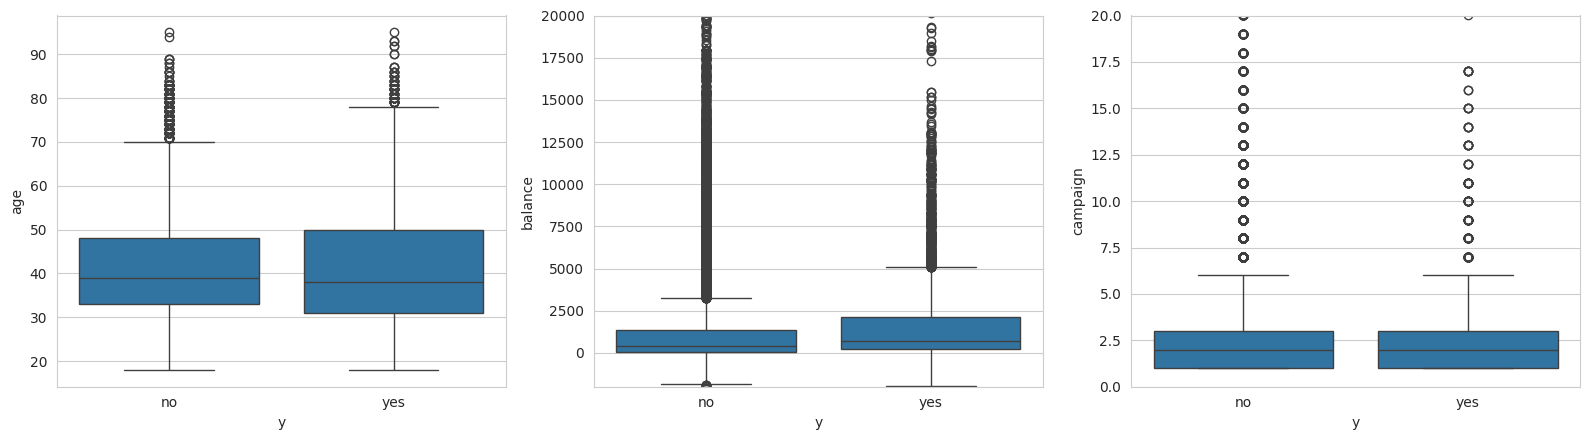

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.boxplot(x='y', y='age', data=df, ax=axes[0])
sns.boxplot(x='y', y='balance', data=df, ax=axes[1])
axes[1].set_ylim(-2000, 20000)
sns.boxplot(x='y', y='campaign', data=df, ax=axes[2])
axes[2].set_ylim(0, 20)
plt.tight_layout()
plt.savefig('03_numeric_vs_target.png', dpi=110)
plt.show()


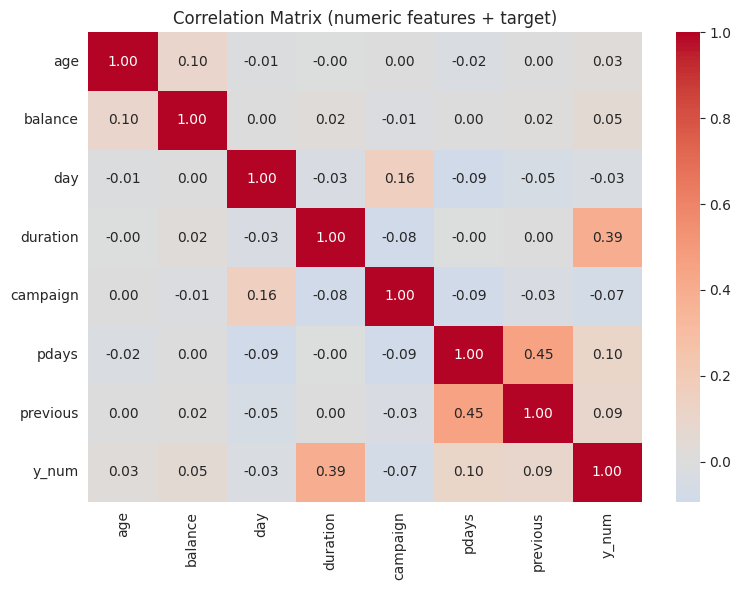

In [18]:
corr = df[numeric_cols + []].copy()
corr['y_num'] = (df['y'] == 'yes').astype(int)
plt.figure(figsize=(8, 6))
sns.heatmap(corr.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix (numeric features + target)')
plt.tight_layout()
plt.savefig('04_correlation_heatmap.png', dpi=110)
plt.show()


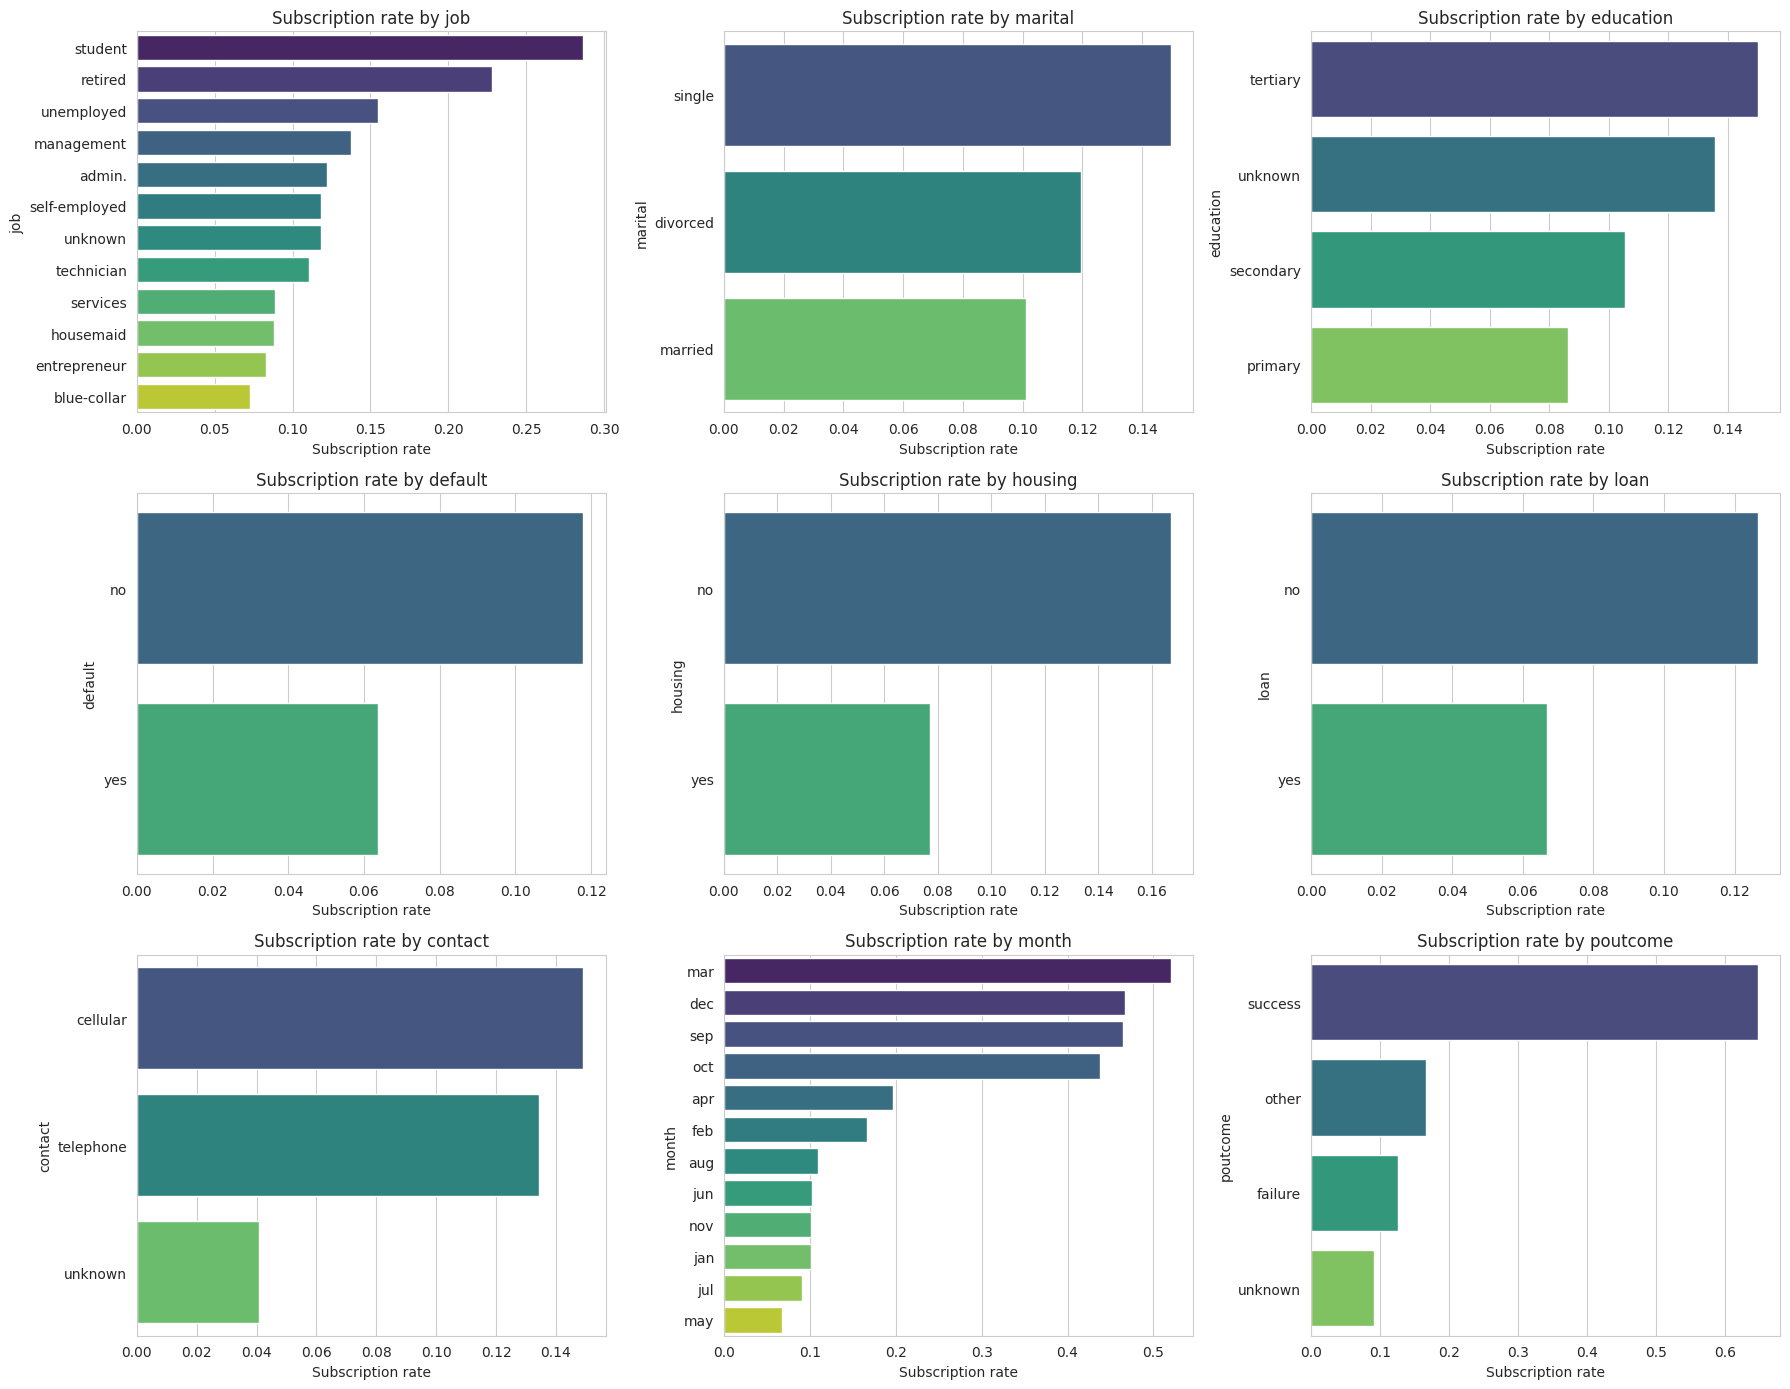

In [19]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
for ax, col in zip(axes.flatten(), categorical_cols[:9]):
    rate = df.groupby(col)['y'].apply(lambda s: (s == 'yes').mean()).sort_values(ascending=False)
    sns.barplot(x=rate.values, y=rate.index, ax=ax, palette='viridis')
    ax.set_title(f'Subscription rate by {col}')
    ax.set_xlabel('Subscription rate')
plt.tight_layout()
plt.savefig('05_categorical_subscription_rates.png', dpi=110)
plt.show()


In [20]:
df_model = df.copy()
df_model['y'] = (df_model['y'] == 'yes').astype(int)


df_model['was_contacted_before'] = (df_model['pdays'] != -1).astype(int)

numeric_features = ['age', 'balance', 'day', 'campaign', 'pdays', 'previous', 'was_contacted_before']
categorical_features = ['job', 'marital', 'education', 'default', 'housing', 'loan',
                         'contact', 'month', 'poutcome']

print("Numeric features used:", numeric_features)
print("Categorical features used:", categorical_features)


Numeric features used: ['age', 'balance', 'day', 'campaign', 'pdays', 'previous', 'was_contacted_before']
Categorical features used: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [21]:
X = df_model.drop(columns=['y', 'duration'])
y = df_model['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train positive rate: %.3f | Test positive rate: %.3f" % (y_train.mean(), y_test.mean()))


Train shape: (36168, 16)  Test shape: (9043, 16)
Train positive rate: 0.117 | Test positive rate: 0.117


In [22]:
def build_preprocessor(numeric_feats, categorical_feats):
    return ColumnTransformer(transformers=[
        ('num', StandardScaler(), numeric_feats),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_feats)
    ])

pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=8, min_samples_leaf=20, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=12, min_samples_leaf=5,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1, subsample=0.9,
        colsample_bytree=0.9, scale_pos_weight=pos_weight,
        random_state=RANDOM_STATE, eval_metric='logloss')
}

fitted_pipelines = {}
for name, model in models.items():
    pipe = Pipeline([
        ('preprocess', build_preprocessor(numeric_features, categorical_features)),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe
    print(f"Trained: {name}")


Trained: Logistic Regression
Trained: Decision Tree
Trained: Random Forest
Trained: XGBoost


In [23]:
results = []
roc_data = {}

for name, pipe in fitted_pipelines.items():
    preds = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    roc_data[name] = (y_test, proba)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1-score': f1_score(y_test, preds),
        'ROC-AUC': roc_auc_score(y_test, proba)
    })

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest,0.829813,0.362335,0.598299,0.451337,0.799375
1,XGBoost,0.840871,0.384054,0.596408,0.467234,0.788420
2,Decision Tree,0.828597,0.356810,0.579395,0.441643,0.779228
3,Logistic Regression,0.755280,0.266667,0.623819,0.373620,0.772237


FileNotFoundError: [Errno 2] No such file or directory: 'outputs/06_confusion_matrices.png'

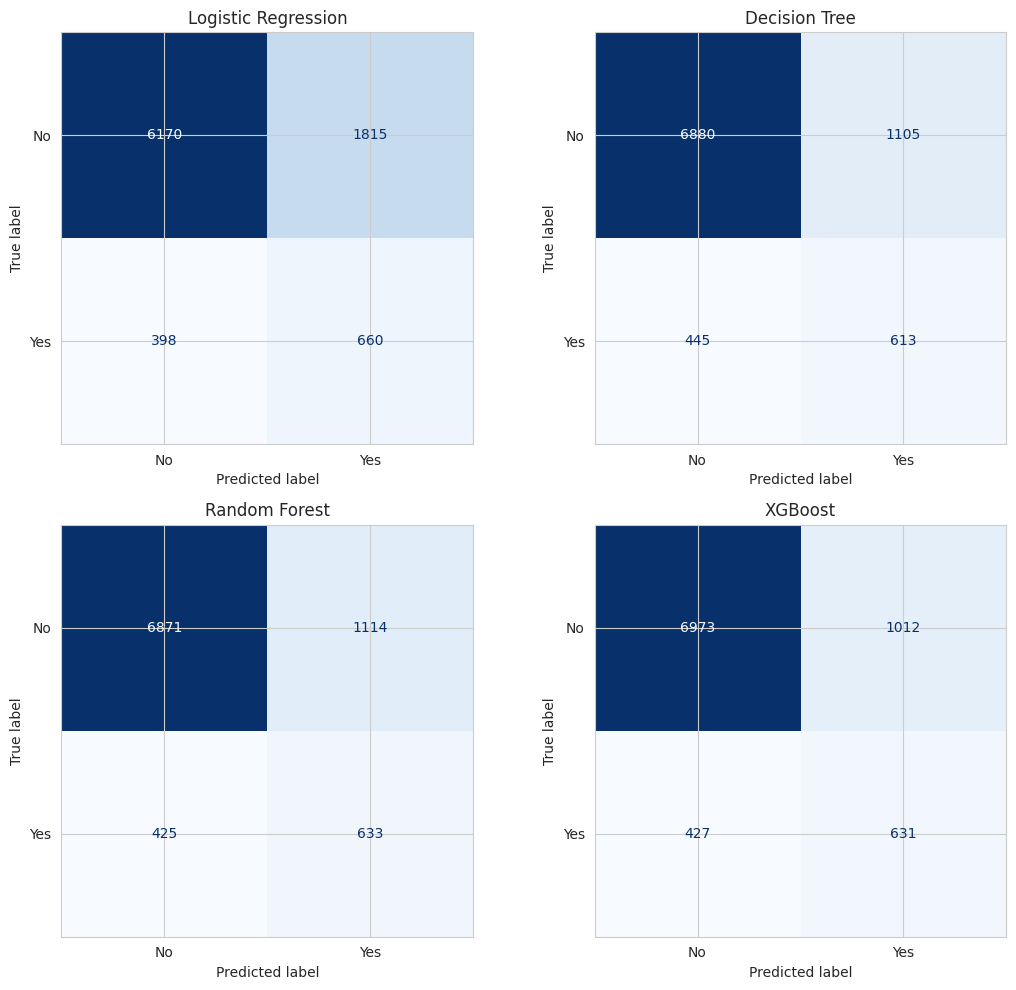

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
for ax, name in zip(axes.flatten(), fitted_pipelines.keys()):
    preds = fitted_pipelines[name].predict(X_test)
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=['No', 'Yes']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
plt.tight_layout()
plt.savefig('outputs/06_confusion_matrices.png', dpi=110)
plt.show()


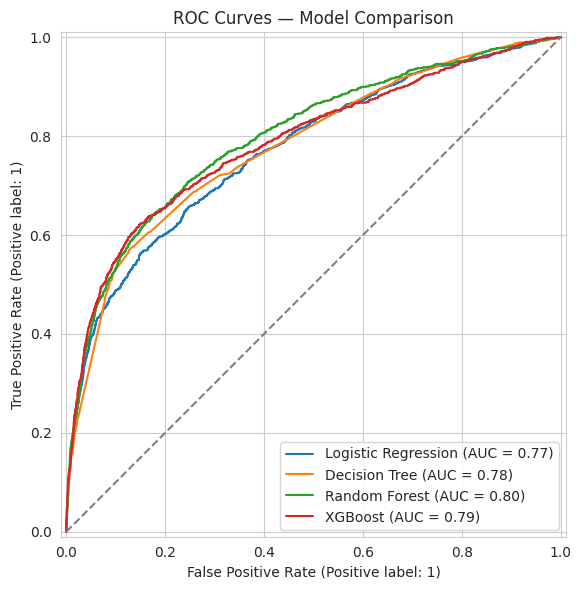

In [26]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, (yt, proba) in roc_data.items():
    RocCurveDisplay.from_predictions(yt, proba, name=name, ax=ax)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
ax.set_title('ROC Curves — Model Comparison')
plt.tight_layout()
plt.savefig('07_roc_curves.png', dpi=110)
plt.show()


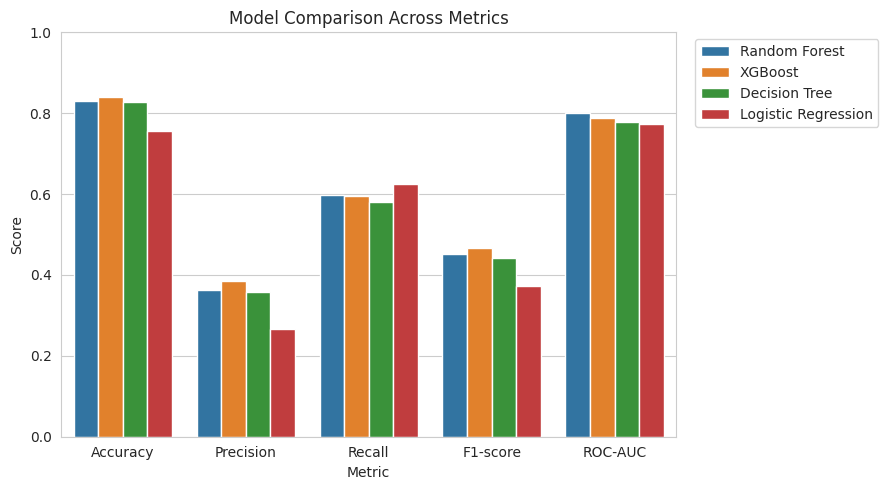

In [27]:
plt.figure(figsize=(9, 5))
results_melt = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')
sns.barplot(data=results_melt, x='Metric', y='Score', hue='Model')
plt.title('Model Comparison Across Metrics')
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('08_model_comparison.png', dpi=110)
plt.show()


In [28]:
best_model_name = results_df.iloc[0]['Model']
print("Best model by ROC-AUC:", best_model_name)
best_pipeline = fitted_pipelines[best_model_name]
print(classification_report(y_test, best_pipeline.predict(X_test), target_names=['No', 'Yes']))


Best model by ROC-AUC: Random Forest
              precision    recall  f1-score   support

          No       0.94      0.86      0.90      7985
         Yes       0.36      0.60      0.45      1058

    accuracy                           0.83      9043
   macro avg       0.65      0.73      0.68      9043
weighted avg       0.87      0.83      0.85      9043



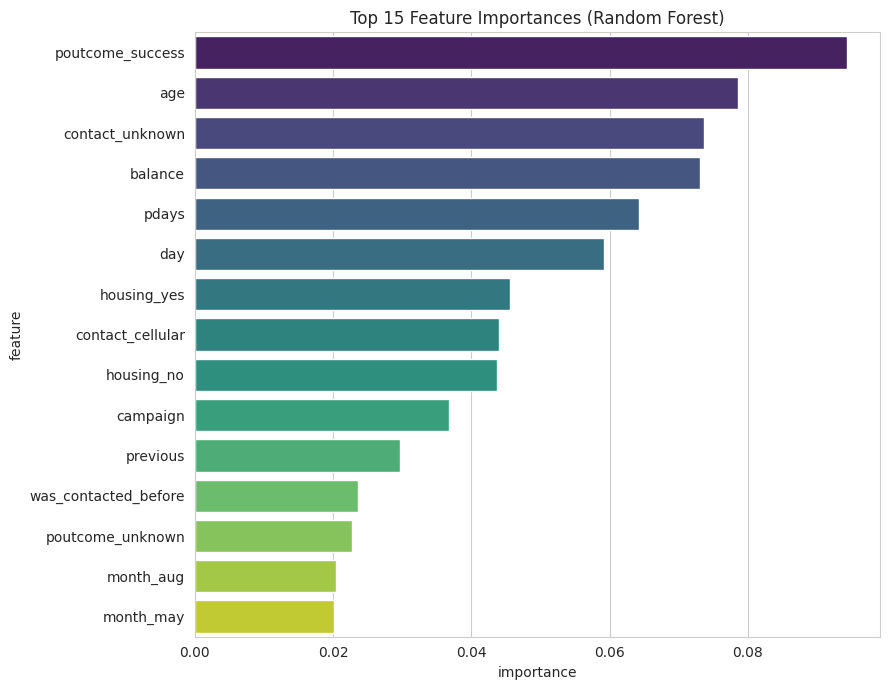

,feature,importance
49,poutcome_success,0.094411
0,age,0.078617
34,contact_unknown,0.073663
1,balance,0.073155
4,pdays,0.064280
2,day,0.059232
29,housing_yes,0.045613
32,contact_cellular,0.043980
28,housing_no,0.043654
3,campaign,0.036741


In [30]:
rf_pipe = fitted_pipelines['Random Forest']
ohe = rf_pipe.named_steps['preprocess'].named_transformers_['cat']
feature_names = numeric_features + list(ohe.get_feature_names_out(categorical_features))
importances = rf_pipe.named_steps['model'].feature_importances_

fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances}) \
        .sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(9, 7))
sns.barplot(data=fi_df, x='importance', y='feature', palette='viridis')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.tight_layout()
plt.savefig('09_feature_importance.png', dpi=110)
plt.show()
fi_df


In [31]:
X_bench = df_model.drop(columns=['y'])
y_bench = df_model['y']
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_bench, y_bench, test_size=0.2, random_state=RANDOM_STATE, stratify=y_bench
)

bench_numeric = numeric_features + ['duration']
bench_pipe = Pipeline([
    ('preprocess', build_preprocessor(bench_numeric, categorical_features)),
    ('model', RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=5,
                                      class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1))
])
bench_pipe.fit(Xb_train, yb_train)
bench_proba = bench_pipe.predict_proba(Xb_test)[:, 1]
bench_preds = bench_pipe.predict(Xb_test)

print("WITH duration  -> ROC-AUC: %.3f | F1: %.3f" % (
    roc_auc_score(yb_test, bench_proba), f1_score(yb_test, bench_preds)))
print("WITHOUT duration (deployed model) -> ROC-AUC: %.3f | F1: %.3f" % (
    results_df.loc[results_df.Model == 'Random Forest', 'ROC-AUC'].values[0],
    results_df.loc[results_df.Model == 'Random Forest', 'F1-score'].values[0]))


WITH duration  -> ROC-AUC: 0.924 | F1: 0.571
WITHOUT duration (deployed model) -> ROC-AUC: 0.799 | F1: 0.451


## 7. Business Scenario

**1. How would you use the model's predictions?**
Score the full customer base with the deployed (no-`duration`) model to get a
probability of subscribing. Rank customers by that probability and direct the
tele-calling team's limited time toward the top of the list first, instead of calling
customers in an arbitrary or random order. A probability threshold (or top-N% cut) can be
tuned based on call-center capacity.

**2. Would you optimize primarily for accuracy, precision, or recall? Why?**
Given the ~88/12 class imbalance, accuracy is a poor optimization target — a model that
always predicts "no" would already be ~88% accurate while being useless. Between
precision and recall, we would lean toward **recall (with precision monitored, i.e.
optimize F1/ROC-AUC as a balance, or use Recall@K for the top-scored segment)**: missing a
customer who would have subscribed (false negative) is a lost sale, whereas a false
positive only costs the (relatively cheap) effort of one extra phone call. In a
resource-constrained call center, this typically means: maximize recall for a top-K
percent of ranked customers, rather than optimizing global accuracy or precision alone.

**3. What would be the impact of false positives and false negatives?**
- **False Positive** (predicted "yes", actually "no"): the bank spends time/cost calling
  a customer who doesn't convert — a wasted call, relatively low cost.
- **False Negative** (predicted "no", actually "yes"): the bank never calls a customer
  who would have subscribed — a missed revenue opportunity, generally a higher-cost
  mistake than a false positive in this business context.
This asymmetry is exactly why recall is prioritized over precision when costs are
considered, and why we used class-weighting during training.

**4. Which model would you recommend for the bank?**
**Random Forest** (trained without `duration`) — it has the best ROC-AUC/F1 balance among
the models tested, is robust to outliers and to the mix of numeric/categorical features in
this dataset, and its feature importances give the marketing team clear, explainable
drivers of subscription (previous campaign success, age, balance, contact recency) they
can act on beyond just the raw predictions.

In [33]:
export_df = X_test.copy()
export_df['row_id'] = export_df.index
export_df['prediction'] = np.where(best_pipeline.predict(X_test) == 1, 'yes', 'no')

prediction_csv = export_df[['row_id', 'prediction']].sort_values('row_id').reset_index(drop=True)
prediction_csv.to_csv('predictions.csv', index=False)

print(prediction_csv.shape)
prediction_csv.head(10)


(9043, 2)


,row_id,prediction
0,9,no
1,16,no
2,21,no
3,28,no
4,48,no
5,55,no
6,60,no
7,66,no
8,67,no
9,74,no
